# Imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..') # path to the src directory
sys.path.append('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonicTesting/')
sys.path.append('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonic_ml/src/')

import pickleJar as pj
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt
# %matplotlib inline
%matplotlib tk

## Import Data

In [2]:
import ultrasonic_ml.data.sqlite_acoustic_data as db
# TODO: is it better to calculate hilbert window in beginning or during visulization?
filepath = '091626_singleroll_scan_1mm_multiplexer.sqlite3' # for now

database = db.AcousticsScanDatabase(filepath)

Establishing SQLite connection to database...
setting paramters
creating analysis and reference tables if they don't exist
computing maxes
Skipping max_voltage_echo_forward as it already exists.
Skipping max_voltage_echo_reverse as it already exists.
Setting global raw maxes...
set_global_raw_maxes took 10.9794 seconds


In [3]:
database.print_schema()

├── parameters
│   ├── gui
│   ├── experiment
│   ├── axis
│   ├── distance
│   ├── transducerFrequency
│   ├── collectionMode
│   ├── pulserType
│   ├── measureTime
│   ├── measureDelay
│   ├── voltageRange
│   ├── autoRange
│   ├── autoRangeEcho
│   ├── waves
│   ├── samples
│   ├── halfCycles
│   ├── multiplexer
│   ├── collectionDirection
│   ├── voltageOffsetForward
│   ├── voltageOffsetReverse
│   ├── gainForward
│   ├── gainReverse
│   ├── picoModule
│   ├── pulseModule
│   ├── rfSwitch
│   ├── t0PulseSwitch
│   ├── t0ReceiveSwitch
│   ├── t1PulseSwitch
│   ├── t1ReceiveSwitch
│   ├── experimentFolder
│   ├── experimentName
│   ├── experimentBaseName
│   ├── saveFormat
│   ├── postAnalysis
│   ├── primaryAxis
│   ├── secondaryAxis
│   ├── primaryAxisRange
│   ├── primaryAxisStep
│   ├── secondaryAxisRange
│   ├── secondaryAxisStep
│   ├── scanInterval
│   ├── numberOfScans
│   ├── pulseInterval
│   ├── experimentTime
│   ├── sweepParams
│   ├── pulserPort
│   ├── scannerPort
│  

## preprocess

In [4]:
for waveform in database.waveform_columns:
    database.preprocess_waveform(
        waveform,
        apply_ungain=False,
        apply_filter=True,
        )

Hilbert transform for voltage_echo_reverse: 100%|██████████| 4681/4681 [00:04<00:00, 1060.64it/s]


Fetching pending...
Updating global analysis max values...
set_global_analysis_maxs took 0.7939 seconds


Hilbert transform for voltage_echo_reverse: 100%|██████████| 4681/4681 [00:00<00:00, 7810.22it/s]


Fetching pending...
Updating global analysis max values...
set_global_analysis_maxs took 0.7154 seconds


## Look at the waveforms only

In [5]:
from ultrasonic_ml.viz import sqlite_clickable_viewer as viz

visualizer = viz.AcousticsScanViewer(database)


tk max_dimensions: 1710 x 1107 px


In [ ]:
# look at raw data
visualizer.show_raw();

In [ ]:
# Look at preprocessed data
visualizer.show_preprocessed(); 

## Look at scan img and waveforms

In [6]:
from ultrasonic_ml.viz import sqlite_clickable_viewer as viz

visualizer = viz.AcousticsScanViewer(database)

In [7]:
visualizer.show_hilbert_scan();

In [8]:
visualizer.show_preprocessed()

In [ ]:
# 1st time slow bc putting the grid into cache
visualizer.show_raw_scan();

In [ ]:
# visualizer.show_raw_scan();

In [ ]:
g_1 = abs(database.fetch_waveform_grid('voltage_echo_forward')).max(axis=1)
g_2 = abs(database.fetch_waveform_grid('voltage_echo_reverse')).max(axis=1)

In [ ]:
database.Z_

31

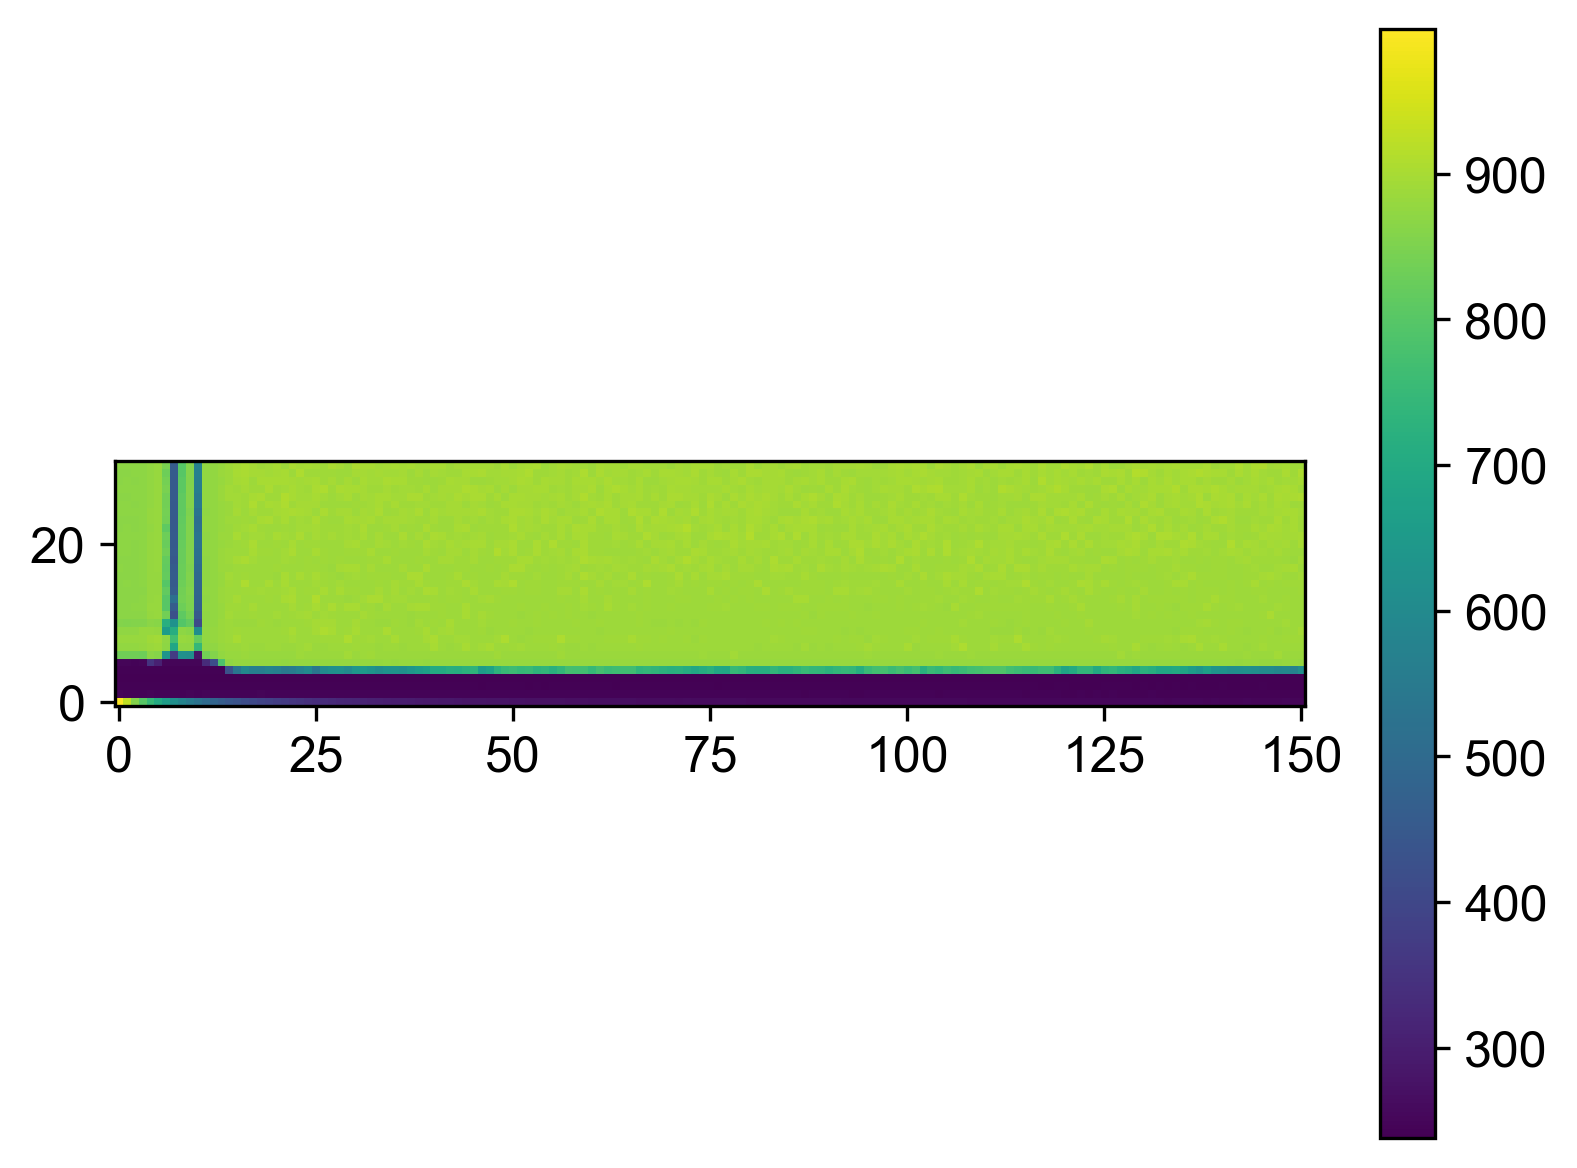

In [ ]:
%matplotlib inline
plt.imshow(g_1.reshape(database.Z_,database.X_, ), origin='lower')
plt.colorbar()

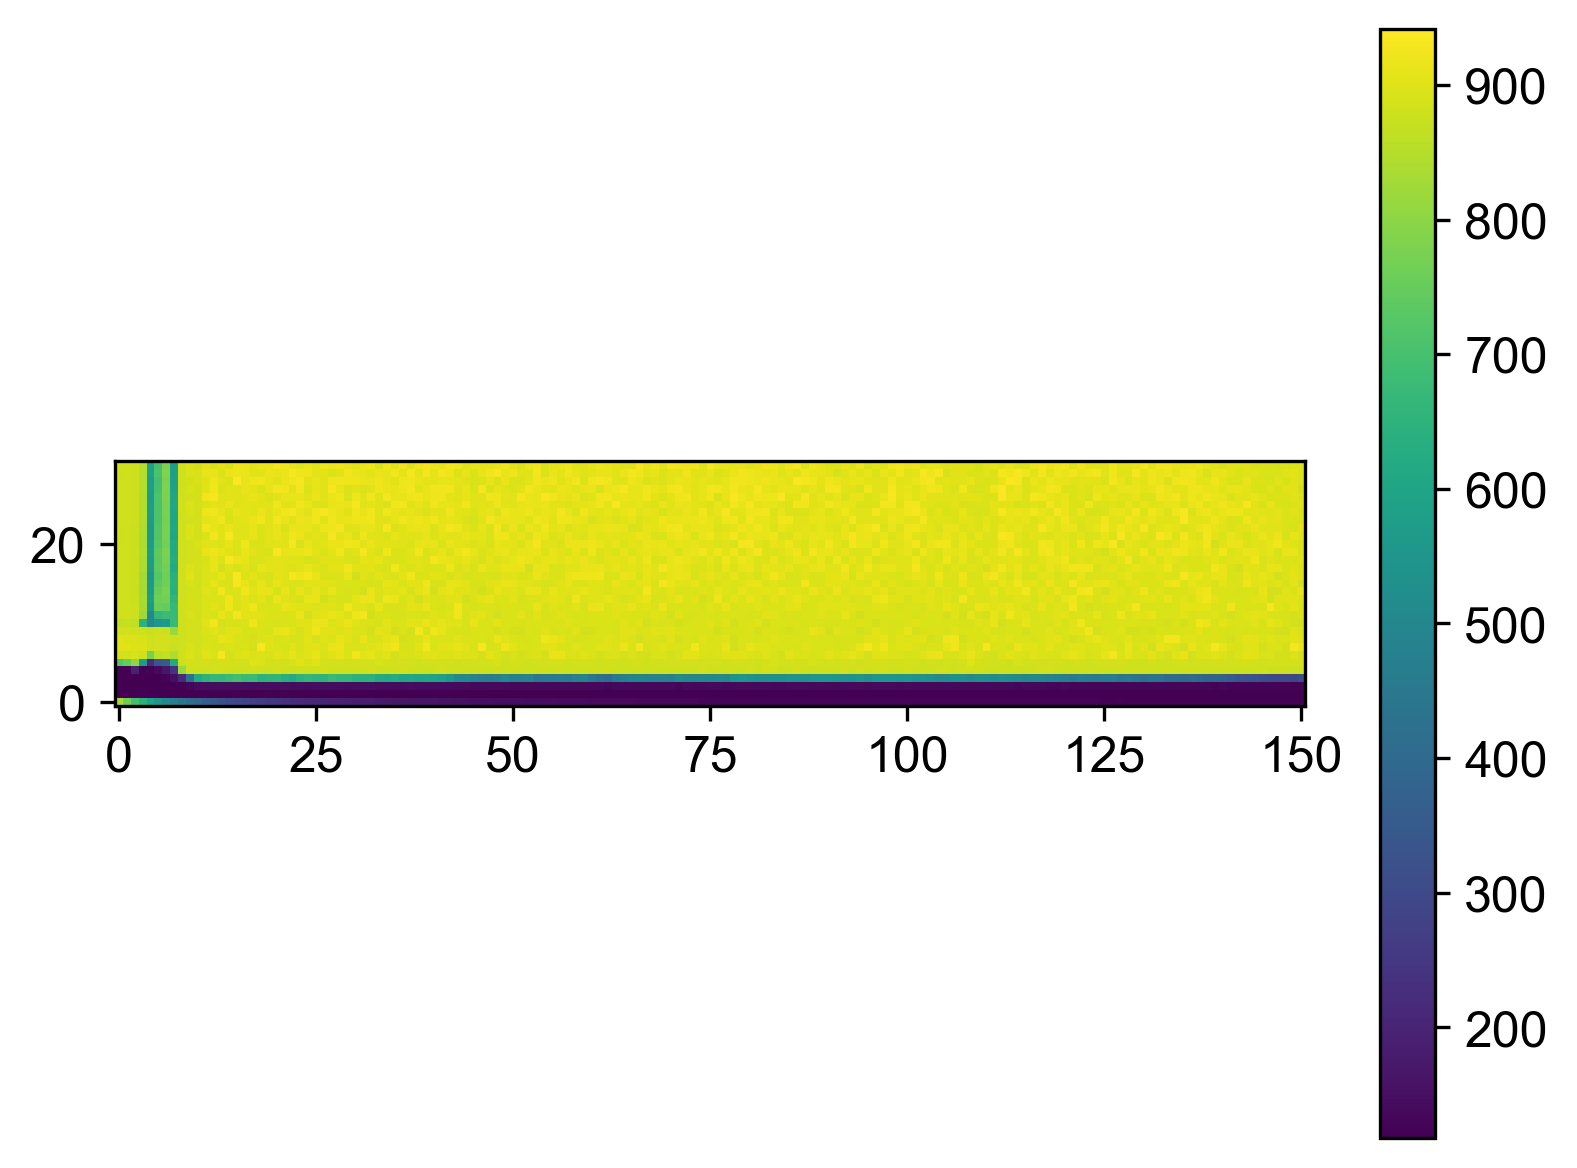

In [ ]:
%matplotlib inline
plt.imshow(g_2.reshape(database.Z_,database.X_, ), origin='lower')
plt.colorbar()

# cont